# Keras para Clasificación

En este laboratorio vamos a armar un modelo de clasificación con Keras para trabajar el dataset MNIST, intentando modelar un reconocedor de dígitos.

### SETUP


In [1]:
!pip install -q tensorflow_cpu==2.18.0
!pip install -q matplotlib==3.9.2
!pip install -q setuptools

In [2]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import keras

from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Input
from keras.utils import to_categorical

import matplotlib.pyplot as plt

## Dataset

En este caso vamos a utilizar un dataset de imagenes de dígitos escritos a mano.

In [3]:
# import the data
from keras.datasets import mnist

# read the data, passed as tuples for train & test
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

Sabemos que las imagenes no son más que una composición matricial de pixeles, nuestras redes neuronales no permiten inputs complejos y por lo tanto debemos "aplastar" la imagen en un arreglo de 1 fila.

In [4]:
print(X_train.shape)

# If image is of size NxM then array should be 1x(N*M)
num_pixels = X_train.shape[1] * X_train.shape[2]  

# Reshape images from NxM to 1x(N*M)
X_train = X_train.reshape(X_train.shape[0], num_pixels).astype('float32') 
X_test = X_test.reshape(X_test.shape[0], num_pixels).astype('float32') 

(60000, 28, 28)


Normalicemos el dataset para que el rango de los pixeles sea de 0-1 y obtengamos la codificación binaria de cada posible categoría (dígitos en rango [0-9]).

In [5]:
# Value normalization
X_train = X_train / 255
X_test = X_test / 255

# Encoding
Y_train = to_categorical(Y_train)
Y_test = to_categorical(Y_test)

num_classes = Y_test.shape[1]

## Construcción de la Red Neuronal

Construyamos dos distintas redes neuronales:

1.  Red Superficial de 2 capas escondidas
2.  Red Profunda de 4 capas escondidas

In [6]:
#Shallow model creation     
shallow_model = Sequential()
shallow_model.add(Input(shape=(num_pixels,))) #Input layer
shallow_model.add(Dense(num_pixels, activation='relu')) #Hidden layer 1
shallow_model.add(Dense(100, activation='relu'))    #Hidden layer 2
shallow_model.add(Dense(num_classes, activation='softmax')) #Output layer w/ Softmax for classification

#Shallow model compilation
shallow_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

deep_model = Sequential()
deep_model.add(Input(shape=(num_pixels,))) #Input layer
deep_model.add(Dense(num_pixels, activation='relu')) #Hidden layer 1
for i in range(4):  deep_model.add(Dense(100, activation='relu'))
deep_model.add(Dense(num_classes, activation='softmax')) #Output layer w/ Softmax for classification

deep_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

### Entrenamiento y Testeo de Modelos

Ahora entrenemos y obtengamos las métricas de los modelos

In [27]:
#Training
shallow_model.fit(X_train, Y_train, validation_data=(X_test, Y_test), epochs=10, verbose=2)
deep_model.fit(X_train, Y_train, validation_data=(X_test,Y_test), epochs=10)

#Testing
shallow_scores = shallow_model.evaluate(X_test,Y_test, verbose=2)
deep_scores = deep_model.evaluate(X_test,Y_test,  verbose=2)

Epoch 1/10
1875/1875 - 5s - 3ms/step - accuracy: 0.9959 - loss: 0.0129 - val_accuracy: 0.9805 - val_loss: 0.0969
Epoch 2/10
1875/1875 - 5s - 3ms/step - accuracy: 0.9954 - loss: 0.0151 - val_accuracy: 0.9822 - val_loss: 0.0943
Epoch 3/10
1875/1875 - 5s - 3ms/step - accuracy: 0.9966 - loss: 0.0111 - val_accuracy: 0.9821 - val_loss: 0.1016
Epoch 4/10
1875/1875 - 5s - 3ms/step - accuracy: 0.9961 - loss: 0.0129 - val_accuracy: 0.9804 - val_loss: 0.1065
Epoch 5/10
1875/1875 - 5s - 3ms/step - accuracy: 0.9966 - loss: 0.0122 - val_accuracy: 0.9815 - val_loss: 0.1131
Epoch 6/10
1875/1875 - 5s - 3ms/step - accuracy: 0.9966 - loss: 0.0113 - val_accuracy: 0.9821 - val_loss: 0.1000
Epoch 7/10
1875/1875 - 5s - 3ms/step - accuracy: 0.9972 - loss: 0.0100 - val_accuracy: 0.9798 - val_loss: 0.1283
Epoch 8/10
1875/1875 - 5s - 3ms/step - accuracy: 0.9970 - loss: 0.0110 - val_accuracy: 0.9824 - val_loss: 0.1131
Epoch 9/10
1875/1875 - 5s - 3ms/step - accuracy: 0.9969 - loss: 0.0119 - val_accuracy: 0.9822 - 

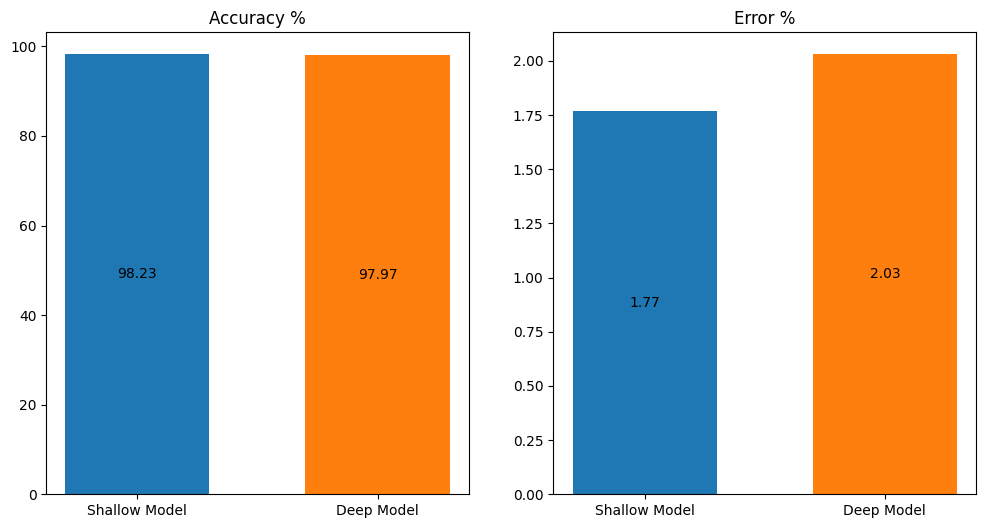

In [26]:
# Plot accuracy and error percentage

plt.figure(figsize=(12, 6))

# Accuracy
ax = plt.subplot(1, 2, 1)
p = ax.bar(["Shallow Model", "Deep Model"], [shallow_scores[1]*100, deep_scores[1] * 100], width=0.6, color=["tab:blue", "tab:orange"])
ax.bar_label(p, label_type="center")
ax.set_title("Accuracy %")

# Error
ax = plt.subplot(1, 2, 2)
p = ax.bar(["Shallow Model", "Deep Model"], [(1 - shallow_scores[1])*100, (1 - deep_scores[1]) * 100], width=0.6, color=["tab:blue", "tab:orange"])
ax.bar_label(p, label_type="center")
ax.set_title("Error %")


plt.show()


## Resultados

Podemos observar que, contrario a lo que uno podría suponer, nuestro modelo superficial obtuvo mejores resultados que el profundo, esto es interesante porque demuestra que no todo se optimiza "insertando capas hasta obtener buenos resultados", es importante ir probando distintas versiones de modelos y encontrar el mas adecuado al problema.